<a href="https://colab.research.google.com/github/terrydw-hcc/ITAI-1371-ML-Labs/blob/main/L07_TerryWilliams_ITAI1371.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 07 Lab - Better Model Evaluation

**Objective:** To move beyond simple accuracy and learn how to use more sophisticated and reliable evaluation techniques, including the confusion matrix, precision, recall, and cross-validation.

**In this lab, you will write the code to generate and interpret these advanced evaluation metrics.**

## Part 1: Setup and Model Training

Let's first train a model so we have something to evaluate. We will use the Titanic dataset again to predict survival.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Load and prepare the Titanic dataset
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

# Encode the 'Sex' column as numeric (0 = male, 1 = female) so the model can use it
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# Fill missing 'Age' values with the median age to keep all rows usable
# Note: assigning back is the safe pattern; chained inplace fillna is deprecated in newer pandas
df['Age'] = df['Age'].fillna(df['Age'].median())

# Define which columns we'll use as inputs (features) and what we're predicting (target)
features = ['Age', 'Pclass', 'Sex', 'Fare']
target = 'Survived'

X = df[features]
y = df[target]

# Split the data: 80% train / 20% test (the held-out 'vault' from the lecture's full workflow)
# random_state=42 makes the split reproducible
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Logistic Regression model on the training set
# max_iter=1000 gives the solver more iterations so it can converge
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Generate predictions on the test set so we can evaluate the model
y_pred = model.predict(X_test)

# Establish the BASELINE -- the lecture stresses this ("Always beat the Baseline").
# A trivial model that always predicts the majority class would score this:
majority_class_baseline = y_test.value_counts(normalize=True).max()
model_accuracy = (y_pred == y_test).mean()

print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")
print(f"Majority-class baseline accuracy: {majority_class_baseline:.2%}")
print(f"Our model's accuracy:             {model_accuracy:.2%}")
print(f"Lift over baseline:               {model_accuracy - majority_class_baseline:+.2%}")

Training samples: 712, Test samples: 179
Majority-class baseline accuracy: 58.66%
Our model's accuracy:             80.45%
Lift over baseline:               +21.79%


## Part 2: The Confusion Matrix

**Concept:** A confusion matrix gives you a more detailed breakdown of a model's performance than accuracy alone. It's a table that shows you where your model got things right and where it got them wrong.

It has four quadrants:
*   **True Positives (TP):** Correctly predicted positive (e.g., predicted survival, and they did survive).
*   **True Negatives (TN):** Correctly predicted negative (e.g., predicted did not survive, and they did not).
*   **False Positives (FP):** Incorrectly predicted positive (e.g., predicted survival, but they did not). Also called a "Type I Error".
*   **False Negatives (FN):** Incorrectly predicted negative (e.g., predicted did not survive, but they did). Also called a "Type II Error".

### Task 1: Generate and Plot a Confusion Matrix

**Your Task:** Use `confusion_matrix` from `sklearn.metrics` to calculate the matrix and `seaborn.heatmap` to visualize it.

Confusion Matrix (raw values):
[[90 15]
 [20 54]]


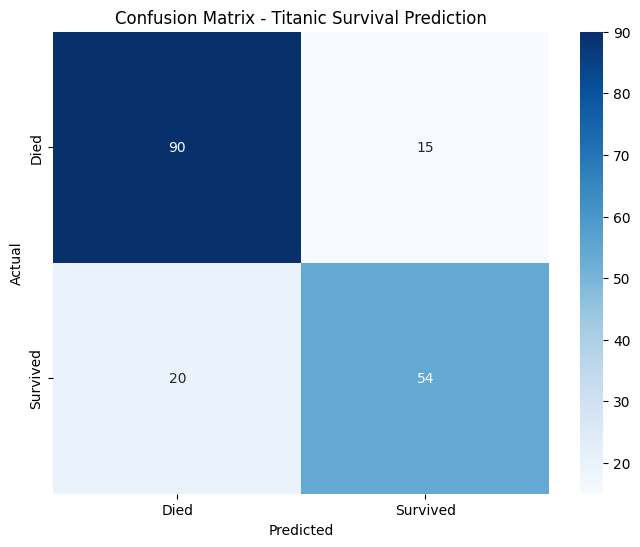


--- Decoding the Quadrants (lecture vocabulary) ---
True Negatives  (predicted Died,     actually Died):     90
False Positives (predicted Survived, actually Died):     15   <-- Type I Error (false alarm)
False Negatives (predicted Died,     actually Survived): 20   <-- Type II Error (missed case)
True Positives  (predicted Survived, actually Survived): 54


In [2]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate the confusion matrix by comparing actual labels (y_test) to predicted labels (y_pred)
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix (raw values):")
print(cm)

# 2. Create a heatmap to visualize the matrix
# annot=True writes the number inside each cell, fmt='d' formats them as integers
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Died', 'Survived'],
            yticklabels=['Died', 'Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Titanic Survival Prediction')
plt.show()

# Unpack the four quadrants and label them with the lecture's Type I / Type II terminology
# .ravel() flattens the 2x2 matrix into [TN, FP, FN, TP]
tn, fp, fn, tp = cm.ravel()
print("\n--- Decoding the Quadrants (lecture vocabulary) ---")
print(f"True Negatives  (predicted Died,     actually Died):     {tn}")
print(f"False Positives (predicted Survived, actually Died):     {fp}   <-- Type I Error (false alarm)")
print(f"False Negatives (predicted Died,     actually Survived): {fn}   <-- Type II Error (missed case)")
print(f"True Positives  (predicted Survived, actually Survived): {tp}")

## Part 3: Precision, Recall, and F1-Score

**Concept:** From the confusion matrix, we can calculate more nuanced metrics:

*   **Precision:** Of all the times the model predicted **positive**, how often was it correct?
    *   Formula: `TP / (TP + FP)`
    *   *Use Case:* When the cost of a **False Positive** is high. (e.g., a spam filter; you don't want to incorrectly mark an important email as spam).

*   **Recall (Sensitivity):** Of all the actual **positives**, how many did the model correctly identify?
    *   Formula: `TP / (TP + FN)`
    *   *Use Case:* When the cost of a **False Negative** is high. (e.g., a medical test for a serious disease; you don't want to miss a real case).

*   **F1-Score:** The harmonic mean of Precision and Recall. It provides a single score that balances both.

### Task 2: Generate a Classification Report

**Your Task:** Use `classification_report` from `sklearn.metrics` to get a summary of these metrics for each class.

In [3]:
from sklearn.metrics import classification_report

# 1. Generate the classification report
# This automatically computes precision, recall, F1-score, and support for each class
# target_names gives the classes readable labels instead of just 0 and 1
report = classification_report(y_test, y_pred, target_names=['Died', 'Survived'])
print("Classification Report:")
print(report)

# Verify the precision and recall formulas from the lecture using our raw TP/FP/FN values
# (computed manually for the 'Survived' positive class so we can see the math line up)
manual_precision = tp / (tp + fp)
manual_recall    = tp / (tp + fn)
manual_f1        = 2 * (manual_precision * manual_recall) / (manual_precision + manual_recall)
print("--- Manual sanity check for the 'Survived' (positive) class ---")
print(f"Precision = TP / (TP + FP) = {tp} / ({tp} + {fp}) = {manual_precision:.3f}")
print(f"Recall    = TP / (TP + FN) = {tp} / ({tp} + {fn}) = {manual_recall:.3f}")
print(f"F1 (harmonic mean of P and R) = {manual_f1:.3f}")

Classification Report:
              precision    recall  f1-score   support

        Died       0.82      0.86      0.84       105
    Survived       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179

--- Manual sanity check for the 'Survived' (positive) class ---
Precision = TP / (TP + FP) = 54 / (54 + 15) = 0.783
Recall    = TP / (TP + FN) = 54 / (54 + 20) = 0.730
F1 (harmonic mean of P and R) = 0.755


## Part 4: Cross-Validation

**Concept:** A single train-test split can be lucky or unlucky. What if, by chance, all the "easy" examples ended up in our test set? Our accuracy score would be misleadingly high.

**Cross-Validation (CV)** solves this. It splits the data into multiple "folds" (e.g., 5 or 10). It then trains and evaluates the model multiple times, using a different fold as the test set each time. The final score is the average of the scores from all folds.

This gives a much more robust and reliable estimate of the model's true performance.

### Task 3: Perform Cross-Validation

**Your Task:** Use `cross_val_score` from `sklearn.model_selection` to perform 5-fold cross-validation on your model.

In [4]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# 1. Perform 5-fold cross-validation
# The lecture's rule (Slide 23): "Always use Stratified K-Fold for Classification."
# Stratified means each fold preserves the same survived/died ratio as the full dataset,
# so no fold accidentally contains all of one class.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=skf, scoring='accuracy')

# 2. Print per-fold scores plus the summary statistics
print(f"Scores for each fold: {cv_scores}")
print(f"Average CV Score: {cv_scores.mean():.2%}")
print(f"Standard Deviation of CV Scores: {cv_scores.std():.4f}")

# Compare to the single-split test accuracy and to the baseline
single_split_accuracy = model.score(X_test, y_test)
print(f"\nSingle train/test split accuracy: {single_split_accuracy:.2%}")
print(f"Majority-class baseline:          {majority_class_baseline:.2%}")

# Report results the "Pro Way" from Slide 27: baseline + variance + business metric
print("\n--- Pro Way Report (per Slide 27) ---")
print(f"  Baseline (majority class):  {majority_class_baseline:.1%}")
print(f"  Model Accuracy (CV):        {cv_scores.mean():.1%} \u00b1 {cv_scores.std():.1%}")
print(f"  Precision (Survived class): {manual_precision:.1%}")
print(f"  Recall    (Survived class): {manual_recall:.1%}")

Scores for each fold: [0.81005587 0.80337079 0.78089888 0.76404494 0.78651685]
Average CV Score: 78.90%
Standard Deviation of CV Scores: 0.0164

Single train/test split accuracy: 80.45%
Majority-class baseline:          58.66%

--- Pro Way Report (per Slide 27) ---
  Baseline (majority class):  58.7%
  Model Accuracy (CV):        78.9% ± 1.6%
  Precision (Survived class): 78.3%
  Recall    (Survived class): 73.0%


## 📝 Knowledge Check

**Instructions:** Answer the following questions in this markdown cell.

1.  **Describe a real-world scenario where you would care more about a model's Precision than its Recall.**
2.  **Describe a real-world scenario where you would care more about a model's Recall than its Precision.**
3.  **Why is a cross-validation score generally more trustworthy than a score from a single train-test split?**

---

### My Answers

**1. A scenario where Precision matters more than Recall:**

An **email spam filter** is the classic case — the lecture frames precision as the "Boy Who Cried Wolf" metric, where every false alarm has a real cost. Here, "positive" means flagging an email as spam. A **False Positive** (Type I Error) is a legitimate email from your boss going to the spam folder — you miss a meeting, miss a deadline, get fired. A **False Negative** is just an unwanted ad sliding into your inbox; you delete it and move on. So the cost asymmetry pushes us hard toward minimizing false positives, which is exactly what high precision optimizes for. We only want the model to scream "SPAM!" when it's truly confident.

Other situations with the same shape: auto-suspending bank accounts for suspected fraud (locking real customers out of their money is worse than letting one suspicious charge through for human review), or auto-rejecting student work for plagiarism (false accusations are far more damaging than missing one cheater).

**2. A scenario where Recall matters more than Precision:**

A **medical screening test for a serious disease like cancer** is the canonical example — the lecture frames recall as the "Missing Child" metric, where missing a real case is catastrophic. Here, a **False Negative** (Type II Error) means telling a sick patient they are healthy; they go home, the disease progresses untreated, and the consequence can be fatal. A **False Positive** is unpleasant — the patient is sent for a follow-up biopsy that turns out clean — but it's recoverable. So we'd rather have many false alarms than miss a single real case, which is exactly what high recall optimizes for.

The same logic applies to fraud detection (better to flag a real charge for a human to review than let actual fraud post) and to security alerting (better to investigate a benign anomaly than to ignore a real intrusion).

**3. Why cross-validation is more trustworthy than a single train-test split:**

The lecture calls this "The Split Problem" — a single train/test split is like grading a student on one pop quiz. They might have just studied that one chapter. If we got a lucky split, the test set has the easiest examples and our accuracy looks great; if we got an unlucky split, the test set has the hardest examples and our accuracy looks terrible. Either way, we don't know which scenario we're in.

Cross-validation fixes this by splitting the data into K folds and rotating which fold is the test set, so every data point ends up in the test set exactly once. We then get K scores instead of one. The **mean** is a much more reliable estimate of true performance, and the **standard deviation** tells us whether the model is *stable* (small std → consistent across folds) or *fragile* (large std → the score depends a lot on which rows it sees, which is a red flag for overfitting or insufficient data). The lecture's "Pro Way" of reporting performance reflects this: never report a bare number — always report it as `mean ± std` against a baseline, because that's the only honest way to communicate how much to trust the result.

An additional note from Slide 23: for classification problems specifically, we should use **Stratified K-Fold** (which I used in Task 3 above) so that each fold preserves the original class balance. Otherwise a random split could put nearly all the "survived" cases into one fold and ruin the evaluation.

## 🤔 Reflection

**What I learned:**

The biggest takeaway from this module is what the lecture calls the **"Accuracy Lie"** — a single accuracy number can hide a useless model. The classic example from class is a fraud detector that predicts "legitimate" for every transaction; on a 999-to-1 imbalanced dataset it scores 99.9% accuracy and catches zero fraud. The Titanic dataset isn't that lopsided, but the lesson generalizes: I now check the **majority-class baseline** before I get excited about an accuracy number, because if my model only beats it by a couple of points, it hasn't really learned anything useful.

The confusion matrix made the failure modes concrete in a way that a single number never could. Once you can *see* the false positives and false negatives separately, the **precision/recall tradeoff** clicks: high precision means a picky model that only fires when sure, high recall means a wide-net model that doesn't want to miss anything, and you genuinely cannot have both maxed out at once. Choosing which one to optimize for has to come from the **business context** — the spam filter and the cancer screen want opposite things, and no purely statistical argument can tell you which to prefer.

**Challenges:**

The trickiest concept wasn't the code (sklearn makes the implementation almost trivial) — it was internalizing why the lecture's rule of "Always use Stratified K-Fold for Classification" matters. With a balanced enough dataset like Titanic, a regular random split usually works fine, so it's tempting to skip the `StratifiedKFold` step. But the moment you hit imbalanced classes (fraud, rare disease, churn), a non-stratified random split can produce a fold with zero positive examples, and your CV score becomes meaningless. Building the habit of using stratified splits *by default* for classification is cheaper than remembering to switch to it later.

**Connections:**

This connects directly back to the train/test split idea from earlier modules. Cross-validation is essentially admitting that one split isn't enough information — we need a *distribution* of scores, not a point estimate. It also connects forward to hyperparameter tuning: as Slide 22 mentioned, you can't honestly tune hyperparameters using your final test set (that's leakage / cheating), so CV becomes the foundation for things like Grid Search, where you need a clean inner loop for tuning that doesn't touch the held-out vault.

**Takeaways for future projects:**

Going forward, my evaluation workflow on any classification problem will follow the lecture's full pipeline:

1. **Split first**, lock the test set in the vault, and don't peek.
2. **Confusion matrix on the validation results** — this is where errors actually live.
3. **Classification report** for precision, recall, and F1 per class.
4. **Stratified K-Fold cross-validation** on the training set for a stable, honest performance estimate.
5. **Report the "Pro Way"** — baseline + mean ± std + the business metric (precision or recall) that actually matters for the use case, not just raw accuracy.

And before any of that, ask the question the lecture kept coming back to: *which mistake is more expensive in this domain, a false positive or a false negative?* That question, not the F1 score, is what should drive the modeling decisions.